In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
from sklearn.datasets import fetch_california_housing #data containing too many outliers, best for RobustScaler()
data = fetch_california_housing()
df = pd.DataFrame(
    data.data,
    columns=data.feature_names
)
df['Price'] = data.target

In [10]:
df.sample(5)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
4809,1.3444,47.0,3.793307,1.104331,1349.0,2.655512,34.03,-118.34,1.250
3734,4.1125,30.0,4.038760,0.976744,306.0,2.372093,34.19,-118.40,2.167
5010,2.4934,44.0,4.754717,1.076651,1622.0,1.912736,34.01,-118.32,1.658
1390,4.6750,33.0,6.360153,1.061303,741.0,2.839080,37.99,-122.12,2.254
20589,1.6652,48.0,4.767380,1.066845,938.0,2.508021,39.15,-121.59,0.589


In [11]:
x=df.drop('Price', axis=1)
y=df['Price']

In [12]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,
                                               y,
                                               test_size=0.2,
                                               random_state=0)
x_train.shape,y_train.shape

((16512, 8), (16512,))

In [13]:
from sklearn.preprocessing import RobustScaler
scaler=RobustScaler()
scaler.fit(x_train)
x_train_scaled=scaler.transform(x_train)
x_test_scaled=scaler.transform(x_test)

In [15]:
x_train_scaled=pd.DataFrame(x_train_scaled,columns=x_train.columns)
x_test_scaled=pd.DataFrame(x_test_scaled,columns=x_test.columns)

In [21]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr_scaled=LinearRegression()
lr.fit(x_train, y_train)
lr_scaled.fit(x_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [17]:
y_pred=lr.predict(x_test)
y_pred_scaled=lr_scaled.predict(x_test_scaled)

<h3>As this is a regression prpblem we have to import r2_score. When there is a classification problem we import accuracy_score</h3>

In [19]:
from sklearn.metrics import r2_score
print("Actual",r2_score(y_test,y_pred))
print("Scaled",r2_score(y_test,y_pred_scaled))

Actual 0.5943232652466193
Scaled 0.5943232652466202


Text(0.5, 1.0, 'After Robust Scaling')

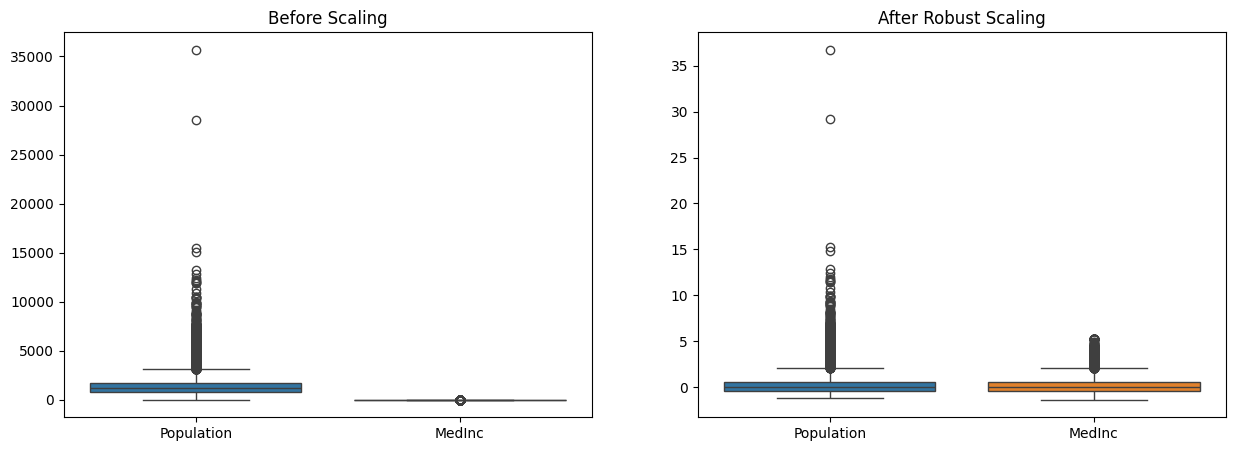

In [24]:
fig,(ax1,ax2)=plt.subplots(ncols=2,figsize=(15,5))
sns.boxplot(data=x_train[['Population','MedInc']],ax=ax1)
ax1.set_title("Before Scaling")

sns.boxplot(data=x_train_scaled[['Population','MedInc']],ax=ax2)
ax2.set_title("After Robust Scaling")

<h3>The boxplot shows that Robust Scaling reduces the effect of extreme outliers by scaling data using median and IQR, while still preserving the outliers themselves.</h3>